# Oolong-synth MemPalace benchmark visualizer

Recursively load every `results.jsonl` under `bench_Oolong_synth/rlm_mempalace_benchmarks/`, aggregate by `(condition, baseline, trial)`, and summarize accuracy, timing, and MemPalace build cost.

The summary table includes **`avg_rlm_time_sec`** (mean of `total_time` per query — RLM-only, separate from MemPalace build) and **`avg_subagent_calls`** (mean of `subagent_calls_mini + subagent_calls_nano` per query).

- **Dependencies:** `pandas`, `matplotlib` — e.g. `uv pip install pandas matplotlib`
- **Working directory:** run from the `rlm` repo root, from `bench_Oolong_synth`, or from any subdirectory under the repo (the config cell walks up to find the root that contains `bench_Oolong_synth`). Override with `REPO_ROOT` if needed.
- **JSONL:** use JSON booleans `true` / `false` (not Python `True` / `False`).
- **Success:** rows with `success: null` are treated as failures for the charts until you run `python -m rlm.utils.eval_success --dir ...` to fill judged `success` / `format_error`.

In [1]:
from __future__ import annotations

from pathlib import Path


def resolve_repo_root() -> Path:
    """Find the repo root as the nearest ancestor of cwd that contains bench_Oolong_synth."""
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "bench_Oolong_synth").is_dir():
            return p
    raise RuntimeError(
        "Could not find a directory containing bench_Oolong_synth starting from "
        f"{here}. Set REPO_ROOT manually to your rlm clone root."
    )


REPO_ROOT = resolve_repo_root()

BENCHMARK_ROOT = REPO_ROOT / "bench_Oolong_synth" / "rlm_mempalace_benchmarks"
# Typical validation slice size; mini-root baseline may use num_trials=2 → 100 rows per file.
EXPECTED_QUERIES_COMMON = 50

In [7]:
import json
import warnings

import pandas as pd


def _condition_for_row(row: dict) -> str:
    raw = row.get("condition")
    if raw is None or (isinstance(raw, str) and not raw.strip()):
        return "(missing)"
    return str(raw)


def _baseline_from_results_path(results_jsonl: Path, json_baseline) -> str:
    """Use folder name so depth runs stay distinct (mirrors BrowseComp-Plus notebook)."""
    parent_name = results_jsonl.parent.name
    if parent_name.endswith("_depth2") or parent_name.endswith("_depth3"):
        return parent_name
    if json_baseline is None:
        return ""
    return str(json_baseline)


def discover_results_jsonl(root: Path) -> list[Path]:
    if not root.is_dir():
        raise NotADirectoryError(f"Not a directory: {root}")
    return sorted(root.rglob("results.jsonl"))


def load_benchmark_jsonl(root: Path) -> pd.DataFrame:
    paths = discover_results_jsonl(root)
    if not paths:
        raise FileNotFoundError(f"No results.jsonl under {root}")
    rows: list[dict] = []
    for path in paths:
        text = path.read_text(encoding="utf-8")
        for lineno, line in enumerate(text.splitlines(), start=1):
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError as e:
                raise ValueError(
                    f"Invalid JSON in {path} line {lineno}: {e.msg}\n"
                    f"Use JSON booleans true/false and null (not Python True/False/None)."
                ) from e
            if not isinstance(obj, dict):
                raise TypeError(f"Expected object per line in {path} line {lineno}")
            obj = dict(obj)
            obj["baseline"] = _baseline_from_results_path(path, obj.get("baseline"))
            obj["condition"] = _condition_for_row(obj)
            obj["source_file"] = str(path)
            rows.append(obj)
    return pd.DataFrame(rows)


df_raw = load_benchmark_jsonl(BENCHMARK_ROOT)
df_raw.head(2)

,task_id,query,baseline,trial,ground_truth,response,subagent_calls_mini,subagent_calls_nano,total_time,input_tokens,...,task_group,answer_type,context_window_id,context_len,context_hash,runner,benchmark_kind,success,format_error,source_file
0,17000208,"In the above data, which of the labels is the ...",flagship-root_mini-sub,1,['numeric value'],Label: numeric value,0,0,6.390282,17222,...,counting,ANSWER_TYPE.LABEL,8,131072,e009fce6c8e0f32c,run_rlm_mempalace_benchmark,oolong_synth_rlm_mempalace,True,False,/Users/dannyyu/Desktop/rlm/bench_Oolong_synth/...
1,17000209,"In the above data, which of the labels is the ...",flagship-root_mini-sub,1,['abbreviation'],Label: abbreviation,0,0,5.513893,17354,...,counting,ANSWER_TYPE.LABEL,8,131072,e009fce6c8e0f32c,run_rlm_mempalace_benchmark,oolong_synth_rlm_mempalace,True,False,/Users/dannyyu/Desktop/rlm/bench_Oolong_synth/...


In [8]:
for col in ("subagent_calls_mini", "subagent_calls_nano"):
    if col not in df_raw.columns:
        raise KeyError(f"Missing required column {col!r} in loaded data")

df = df_raw.copy()
if "trial" not in df.columns:
    df["trial"] = 1
df["trial"] = pd.to_numeric(df["trial"], errors="raise").astype(int)

df["subagent_calls_total"] = df["subagent_calls_mini"].fillna(0) + df[
    "subagent_calls_nano"
].fillna(0)

if "format_error" not in df.columns:
    df["format_error"] = False
else:
    df["format_error"] = df["format_error"].fillna(False).astype(bool)

# null success (unevaluated) counts as not successful for aggregate charts
df["success"] = df["success"].fillna(False).astype(bool)
df["model_error"] = (~df["success"]) & (~df["format_error"])

df["_no_format_error"] = ~df["format_error"]
df["_success_no_format_error"] = df["success"] & df["_no_format_error"]

if "mempalace_build_seconds" in df.columns:
    df["mempalace_build_seconds"] = pd.to_numeric(
        df["mempalace_build_seconds"], errors="coerce"
    ).fillna(0.0)
else:
    df["mempalace_build_seconds"] = 0.0

group_cols = ["condition", "baseline", "trial"]
summary = (
    df.groupby(group_cols, dropna=False)
    .agg(
        success_rate=("success", "mean"),
        avg_rlm_time_sec=("total_time", "mean"),
        avg_input_token=("input_tokens", "mean"),
        avg_mempalace_build_sec=("mempalace_build_seconds", "mean"),
        sum_mempalace_build_sec=("mempalace_build_seconds", "sum"),
        avg_subagent_calls=("subagent_calls_total", "mean"),
        n_queries=("task_id", "count"),
        n_format_errors=("format_error", "sum"),
        n_model_errors=("model_error", "sum"),
        _denom_no_fmt=("_no_format_error", "sum"),
        _num_succ_no_fmt=("_success_no_format_error", "sum"),
    )
    .reset_index()
    .sort_values(["condition", "baseline", "trial"], kind="stable")
)

_denom = summary["_denom_no_fmt"].astype(float)
_num = summary["_num_succ_no_fmt"].astype(float)
summary["norm_success_rate"] = (_num / _denom.where(_denom > 0)).astype(float)
summary = summary.drop(columns=["_denom_no_fmt", "_num_succ_no_fmt"])

summary = summary[
    [
        "condition",
        "baseline",
        "trial",
        "success_rate",
        "norm_success_rate",
        "n_format_errors",
        "n_model_errors",
        "avg_rlm_time_sec",
        "avg_input_token",
        "avg_mempalace_build_sec",
        "sum_mempalace_build_sec",
        "avg_subagent_calls",
        "n_queries",
    ]
]

bad_n = summary[~summary["n_queries"].isin((EXPECTED_QUERIES_COMMON, EXPECTED_QUERIES_COMMON * 2))]
if len(bad_n):
    for _, r in bad_n.iterrows():
        warnings.warn(
            f"Unusual n_queries={int(r['n_queries'])} for "
            f"condition={r['condition']!r} baseline={r['baseline']!r} trial={r['trial']!r} "
            f"(expected {EXPECTED_QUERIES_COMMON} or {EXPECTED_QUERIES_COMMON * 2} for typical synth slate)",
            stacklevel=1,
        )

summary

,condition,baseline,trial,success_rate,norm_success_rate,n_format_errors,n_model_errors,avg_rlm_time_sec,avg_input_token,avg_mempalace_build_sec,sum_mempalace_build_sec,avg_subagent_calls,n_queries
0,palace_poc_strict_by_record,flagship-root_mini-sub,1,0.84,0.913043,4,4,17.436042,57343.52,9.619513,480.975631,0.0,50
1,palace_poc_strict_by_record,flagship-root_mini-sub_gpt5,1,0.76,0.760000,0,12,116.090804,39160.06,9.780041,489.002029,0.0,50
2,palace_poc_strict_by_record,mini-root_mini-sub,1,0.78,0.780000,0,11,37.694430,206449.84,9.675836,483.791795,0.0,50
3,palace_poc_strict_by_record,mini-root_mini-sub,2,0.78,0.780000,0,11,36.841053,203090.00,9.675836,483.791795,0.0,50


In [13]:
from IPython.display import display

display(summary)

,condition,baseline,trial,success_rate,norm_success_rate,n_format_errors,n_model_errors,avg_rlm_time_sec,avg_input_token,avg_mempalace_build_sec,sum_mempalace_build_sec,avg_subagent_calls,n_queries
0,palace_poc_strict_by_block,mini-root_mini-sub,1,0.1,0.1,0,45,59.247427,419610.66,0.0,0.0,152.46,50


In [9]:
from IPython.display import display

# Optional: success rate by task_group (requires column on rows)
if "task_group" in df.columns:
    by_task = (
        df.groupby(["baseline", "task_group"], dropna=False)["success"]
        .mean()
        .reset_index()
        .sort_values(["baseline", "task_group"], kind="stable")
    )
    display(by_task.head(20))
else:
    print("No task_group column; skip breakdown.")

,baseline,task_group,success
0,flagship-root_mini-sub,counting,0.909091
1,flagship-root_mini-sub,user,0.705882
2,flagship-root_mini-sub_gpt5,counting,0.909091
3,flagship-root_mini-sub_gpt5,user,0.470588
4,mini-root_mini-sub,counting,0.984848
5,mini-root_mini-sub,user,0.382353


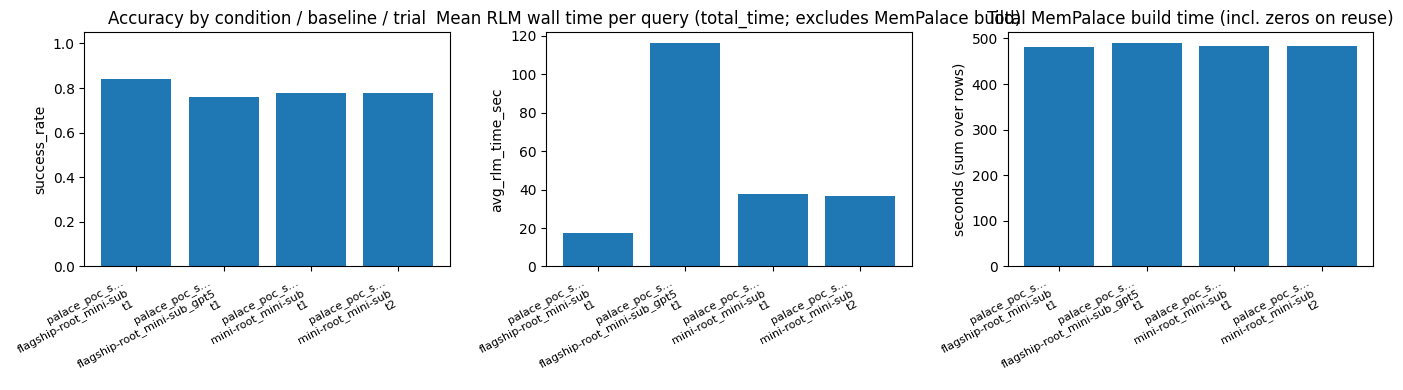

In [10]:
import matplotlib.pyplot as plt

labels = []
for row in summary.itertuples(index=False):
    c = str(row.condition)
    labels.append(
        f"{c[:12]}…\n{row.baseline}\nt{row.trial}" if len(c) > 12 else f"{c}\n{row.baseline}\nt{row.trial}"
    )
x = range(len(summary))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax0 = axes[0]
ax0.bar(x, summary["success_rate"].to_numpy())
ax0.set_xticks(list(x))
ax0.set_xticklabels(labels, rotation=28, ha="right", fontsize=8)
ax0.set_ylabel("success_rate")
ax0.set_ylim(0, 1.05)
ax0.set_title("Accuracy by condition / baseline / trial")

ax1 = axes[1]
ax1.bar(x, summary["avg_rlm_time_sec"].to_numpy())
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=28, ha="right", fontsize=8)
ax1.set_ylabel("avg_rlm_time_sec")
ax1.set_title("Mean RLM wall time per query (total_time; excludes MemPalace build)")

ax2 = axes[2]
ax2.bar(x, summary["sum_mempalace_build_sec"].to_numpy())
ax2.set_xticks(list(x))
ax2.set_xticklabels(labels, rotation=28, ha="right", fontsize=8)
ax2.set_ylabel("seconds (sum over rows)")
ax2.set_title("Total MemPalace build time (incl. zeros on reuse)")

fig.tight_layout()
plt.show()

In [12]:
OOLONG_REAL_ROOT = REPO_ROOT / "bench_Oolong_real" / "rlm_mempalace_benchmarks"
oolong_real_df = load_benchmark_jsonl(OOLONG_REAL_ROOT)

for col in ("subagent_calls_mini", "subagent_calls_nano"):
    if col not in oolong_real_df.columns:
        raise KeyError(f"Missing required column {col!r} in loaded data")

oolong_real_df = oolong_real_df.copy()
if "trial" not in oolong_real_df.columns:
    oolong_real_df["trial"] = 1
oolong_real_df["trial"] = pd.to_numeric(oolong_real_df["trial"], errors="raise").astype(int)

oolong_real_df["subagent_calls_total"] = oolong_real_df["subagent_calls_mini"].fillna(0) + oolong_real_df[
    "subagent_calls_nano"
].fillna(0)

if "format_error" not in oolong_real_df.columns:
    oolong_real_df["format_error"] = False
else:
    oolong_real_df["format_error"] = oolong_real_df["format_error"].fillna(False).astype(bool)

# null success (unevaluated) counts as not successful for aggregate charts
oolong_real_df["success"] = oolong_real_df["success"].fillna(False).astype(bool)
oolong_real_df["model_error"] = (~oolong_real_df["success"]) & (~oolong_real_df["format_error"])

oolong_real_df["_no_format_error"] = ~oolong_real_df["format_error"]
oolong_real_df["_success_no_format_error"] = oolong_real_df["success"] & oolong_real_df["_no_format_error"]

if "mempalace_build_seconds" in oolong_real_df.columns:
    oolong_real_df["mempalace_build_seconds"] = pd.to_numeric(
        oolong_real_df["mempalace_build_seconds"], errors="coerce"
    ).fillna(0.0)
else:
    oolong_real_df["mempalace_build_seconds"] = 0.0

group_cols = ["condition", "baseline", "trial"]
summary = (
    oolong_real_df.groupby(group_cols, dropna=False)
    .agg(
        success_rate=("success", "mean"),
        avg_rlm_time_sec=("total_time", "mean"),
        avg_input_token=("input_tokens", "mean"),
        avg_mempalace_build_sec=("mempalace_build_seconds", "mean"),
        sum_mempalace_build_sec=("mempalace_build_seconds", "sum"),
        avg_subagent_calls=("subagent_calls_total", "mean"),
        n_queries=("task_id", "count"),
        n_format_errors=("format_error", "sum"),
        n_model_errors=("model_error", "sum"),
        _denom_no_fmt=("_no_format_error", "sum"),
        _num_succ_no_fmt=("_success_no_format_error", "sum"),
    )
    .reset_index()
    .sort_values(["condition", "baseline", "trial"], kind="stable")
)

_denom = summary["_denom_no_fmt"].astype(float)
_num = summary["_num_succ_no_fmt"].astype(float)
summary["norm_success_rate"] = (_num / _denom.where(_denom > 0)).astype(float)
summary = summary.drop(columns=["_denom_no_fmt", "_num_succ_no_fmt"])

summary = summary[
    [
        "condition",
        "baseline",
        "trial",
        "success_rate",
        "norm_success_rate",
        "n_format_errors",
        "n_model_errors",
        "avg_rlm_time_sec",
        "avg_input_token",
        "avg_mempalace_build_sec",
        "sum_mempalace_build_sec",
        "avg_subagent_calls",
        "n_queries",
    ]
]

bad_n = summary[~summary["n_queries"].isin((EXPECTED_QUERIES_COMMON, EXPECTED_QUERIES_COMMON * 2))]
if len(bad_n):
    for _, r in bad_n.iterrows():
        warnings.warn(
            f"Unusual n_queries={int(r['n_queries'])} for "
            f"condition={r['condition']!r} baseline={r['baseline']!r} trial={r['trial']!r} "
            f"(expected {EXPECTED_QUERIES_COMMON} or {EXPECTED_QUERIES_COMMON * 2} for typical synth slate)",
            stacklevel=1,
        )

summary

,condition,baseline,trial,success_rate,norm_success_rate,n_format_errors,n_model_errors,avg_rlm_time_sec,avg_input_token,avg_mempalace_build_sec,sum_mempalace_build_sec,avg_subagent_calls,n_queries
0,palace_poc_strict_by_block,mini-root_mini-sub,1,0.1,0.1,0,45,59.247427,419610.66,0.0,0.0,152.46,50
